# German Credit Risk - End-to-End Project

## 1. Business Understanding

### 1.1 Project Objective

The objective of this project is to build an end-to-end credit risk analytics solution using the German Credit dataset. The project focuses on analyzing applicant financial profiles, identifying key risk drivers, and developing predictive models to classify customers according to their credit risk level.

### 1.2 Credit Risk Problem Definition

Credit risk refers to the possibility that a borrower may fail to repay a loan according to agreed terms. For financial institutions, poor credit decisions can lead to increased default rates, financial losses, and inefficient use of capital.

The main challenge is to distinguish between reliable applicants and potentially risky borrowers before granting credit. This requires balancing two business goals:

- Approving creditworthy customers efficiently  
- Detecting high-risk applicants early

In this dataset, applicants are labeled as:

- Good Risk  
- Bad Risk

Therefore, the problem is treated as a supervised binary classification task.

### 1.3 Success Metrics

The success of the project will be evaluated using both predictive performance and business relevance.

#### Model Performance Metrics

- Accuracy  
- Precision  
- Recall  
- F1-Score  
- ROC-AUC  

#### Business Metrics

- Correct identification of bad-risk applicants  
- Reduction of potential loan defaults  
- Explainability of model decisions  
- Support for better lending decisions  

Special emphasis will be placed on Recall for bad-risk applicants, since failing to identify risky borrowers can lead to direct financial losses.

## 2. Data Loading

### 2.1 Import Libraries

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

In [57]:
from sklearn.preprocessing import (
    StandardScaler, 
    OneHotEncoder, 
    OrdinalEncoder
)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score,
    confusion_matrix,
    classification_report
)


### 2.2 Load Dataset

In [58]:
project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent

data_path = project_root / "data" / "german_credit_data.csv"
df = pd.read_csv(data_path, index_col=0)

### 2.3 Preview Data

In [59]:
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


## 3. Data Inspection

### 3.1 Dataset Shape

In [60]:
df.shape

(1000, 10)

### 3.2 Column Overview

In [61]:
df.columns.to_list()

['Age',
 'Sex',
 'Job',
 'Housing',
 'Saving accounts',
 'Checking account',
 'Credit amount',
 'Duration',
 'Purpose',
 'Risk']

### 3.3 Data Types

In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   str  
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   str  
 4   Saving accounts   817 non-null    str  
 5   Checking account  606 non-null    str  
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   str  
 9   Risk              1000 non-null   str  
dtypes: int64(4), str(6)
memory usage: 78.3 KB


### 3.4 Numerical Feature Summary

In [63]:
df.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


### 3.5 Categorical Feature Distribution

In [64]:
print('Categorical features:\n')
for col in df.select_dtypes(include=['object']).columns.to_list():
    
    print(df[col].value_counts(normalize=True, dropna=False))
    print('\n')

Categorical features:

Sex
male      0.69
female    0.31
Name: proportion, dtype: float64


Housing
own     0.713
rent    0.179
free    0.108
Name: proportion, dtype: float64


Saving accounts
little        0.603
NaN           0.183
moderate      0.103
quite rich    0.063
rich          0.048
Name: proportion, dtype: float64


Checking account
NaN         0.394
little      0.274
moderate    0.269
rich        0.063
Name: proportion, dtype: float64


Purpose
car                    0.337
radio/TV               0.280
furniture/equipment    0.181
business               0.097
education              0.059
repairs                0.022
domestic appliances    0.012
vacation/others        0.012
Name: proportion, dtype: float64


Risk
good    0.7
bad     0.3
Name: proportion, dtype: float64




### 3.6 Missing Values Summary

In [65]:
df.isna().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

### 3.7  Initial Observations

Based on the inspection phase:
- The dataset contains both categorical and numerical variables.
- Missing values are concentrated in account-related features (Saving and checking account features).
- The target variable shows moderate imbalance (70% good, 30% bad).
- Most customers own their housing.
- Loan purposes are dominated by car and consumer electronics.
- Gender distribution is skewed toward male applicants.

## 4. Data Cleaning

### 4.1 Rename Columns
Column names are standardized to lowercase format with underscores for easier handling in Python workflows.

In [66]:
df.columns = (
    df.columns
    .str.lower()
    .str.strip()
    .str.replace(' ','_')
)
df.columns

Index(['age', 'sex', 'job', 'housing', 'saving_accounts', 'checking_account',
       'credit_amount', 'duration', 'purpose', 'risk'],
      dtype='str')

### 4.2 Handle Missing Values

Missing values are present in saving_accounts and checking_account.
Since missingness may contain business meaning, missing categories are replaced with "unknown".

In [67]:
df["saving_accounts"] = df["saving_accounts"].fillna("unknown")
df["checking_account"] = df["checking_account"].fillna("unknown")

In [68]:
df.isna().sum()

age                 0
sex                 0
job                 0
housing             0
saving_accounts     0
checking_account    0
credit_amount       0
duration            0
purpose             0
risk                0
dtype: int64

### 4.3 Check Duplicate Records

In [69]:
df.duplicated().sum()

np.int64(0)

### 4.4 Correct Data Types

In [70]:
cat_cols = df.select_dtypes(include=['object']).columns.to_list()
cat_cols.append('job')

for col in cat_cols:
    df[col] = df[col].astype('category')

In [71]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   age               1000 non-null   int64   
 1   sex               1000 non-null   category
 2   job               1000 non-null   category
 3   housing           1000 non-null   category
 4   saving_accounts   1000 non-null   category
 5   checking_account  1000 non-null   category
 6   credit_amount     1000 non-null   int64   
 7   duration          1000 non-null   int64   
 8   purpose           1000 non-null   category
 9   risk              1000 non-null   category
dtypes: category(7), int64(3)
memory usage: 30.6 KB


## 5. Exploratory Data Analysis (EDA)

### 5.1 Objective

The purpose of exploratory data analysis is to understand customer characteristics, identify important patterns, detect potential risk drivers, and generate business insights before predictive modeling.

### 5.2 Univariate Analysis


#### 5.2.1 Target Variable Distribution

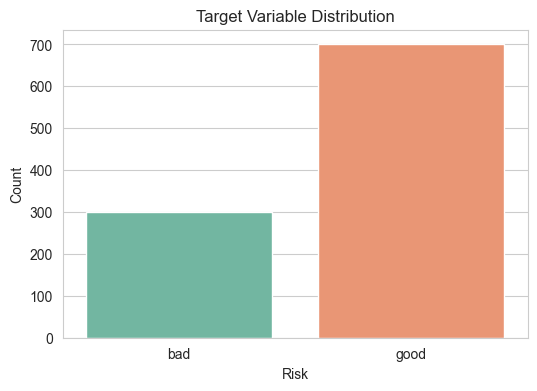

In [72]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="risk", palette="Set2")
plt.title("Target Variable Distribution")
plt.xlabel("Risk")
plt.ylabel("Count")
plt.show()


**Insights — target variable (5.2.1)**

- The dataset is **imbalanced**: about **700 good** vs **300 bad** cases (**~70% / 30%**). Accuracy alone can be misleading; prefer **ROC–AUC**, **PR–AUC**, and **confusion-matrix** metrics with **stratified** train/validation splits.
- If the business cost of missing a **bad** risk is high, emphasize **recall** (or cost-sensitive thresholds) for the bad class when tuning and reporting.


#### 5.2.2 Numerical Features

In [73]:
num_cols = df.select_dtypes(include=['int64']).columns.to_list()

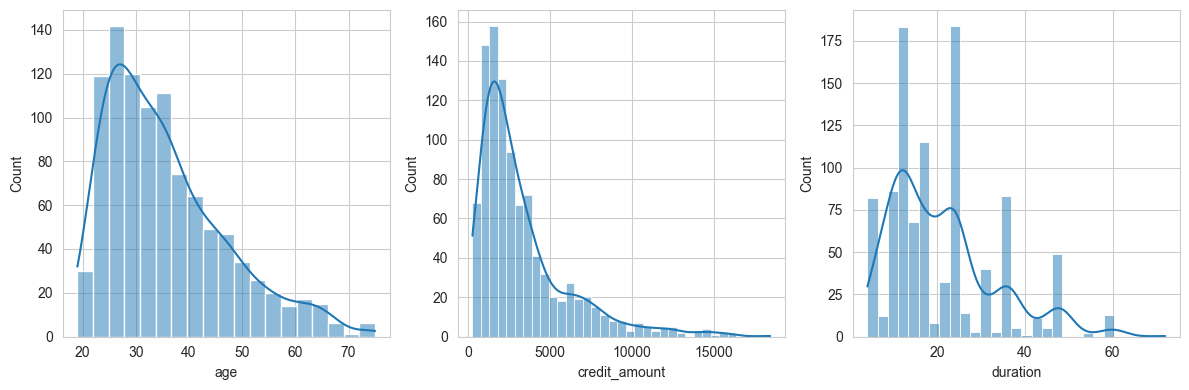

In [74]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

for i, col in enumerate(num_cols):
    sns.histplot(x=df[col], ax=axes[i], kde=True, palette="Set2")

plt.tight_layout()
plt.show()


**Insights — numerical distributions (5.2.2)**

- **Age** is broadly unimodal with most applicants in the **30–40** range; tails are thinner at very young and very old ages.
- **Credit amount** is **right-skewed**: many smaller loans and a long tail of large exposures—typical for consumer credit portfolios.
- **Duration** is also right-skewed toward **shorter** maturities, with a tail of longer terms.
- Skew motivates **robust scaling**, optional **log transforms**, or **tree-based models** that handle heavy tails without strict linearity assumptions.


#### 5.2.3 Categorical Features

['sex', 'job', 'housing', 'saving_accounts', 'checking_account', 'purpose']


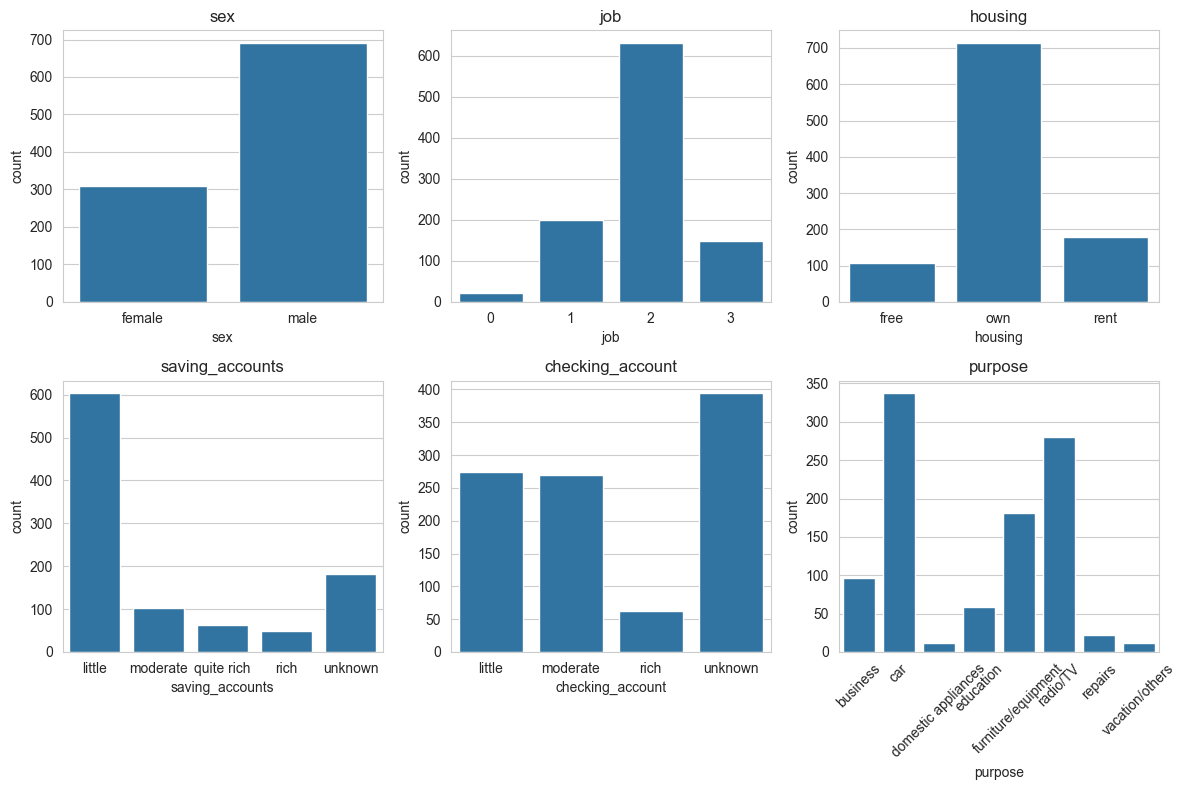

In [75]:
cat_features = df.select_dtypes(include=['category']).columns.to_list()
cat_features.remove('risk')
print(cat_features)

fig, axis = plt.subplots(2, 3, figsize=(12, 8))
axis = axis.flatten()

for i, col in enumerate(cat_features):
    sns.countplot(data=df, x=col, ax=axis[i])
    axis[i].set_title(col)
    if col == 'purpose':
        axis[i].tick_params(axis='x', labelrotation=45)

plt.tight_layout()

**Insights — categorical distributions (5.2.3)**

- Several variables (**checking account**, **saving accounts**, **purpose**) are **unevenly populated**; interpret rare categories cautiously and consider **grouping levels** if counts are very small.
- Missing **saving** / **checking** information was mapped to **“unknown”**, which becomes an explicit level—useful for the model because **missingness itself** can carry signal.


### 5.3 Bivariate Analysis

#### 5.3.1 Numerical Features vs Risk

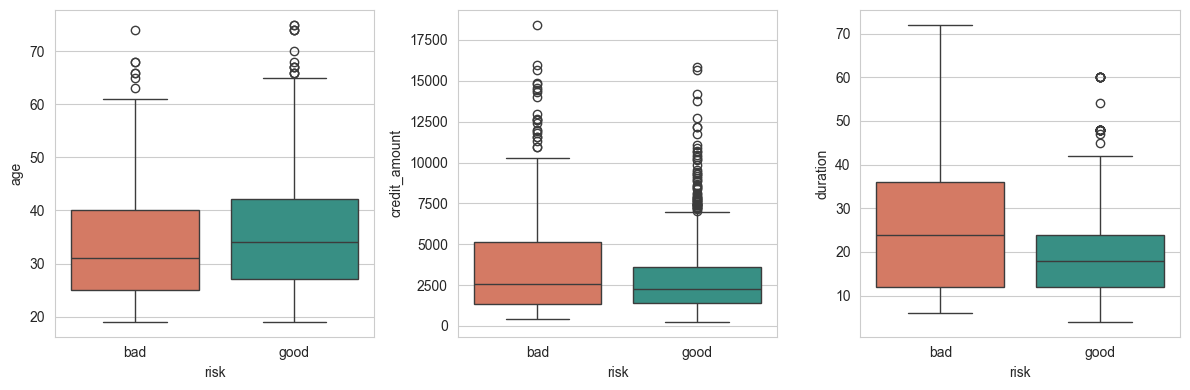

In [76]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

risk_colors = {
    "bad": "#e76f51",   # red
    "good": "#2a9d8f"   # green
}

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x="risk", y=df[col],ax=axes[i], palette=risk_colors)

plt.tight_layout()
plt.show()


**Insights — numerical features vs. risk (5.3.1)**

- **Duration** shows the clearest separation: **bad** risk loans have a **higher median** (~**24** vs ~**18** months) and a wider spread—longer repayment horizons align with higher observed default risk in this sample.
- **Credit amount** is higher among **bad** cases (median ~**2,574** vs ~**2,244**; means ~**3,938** vs ~**2,986**), consistent with larger obligations stretching repayment capacity.
- **Age** differs more modestly between risk groups; it is likely a **weaker univariate signal** than amount or duration but can still contribute in multivariate models.

Overall, **amount** and **duration** jointly match the intuition that **larger, longer** loans are harder to service—worth prioritizing in feature importance and policy discussions.


In [77]:
# fig, axes = plt.subplots(1, 3, figsize=(14,4))
# risk_colors = {
#     "bad": "#e76f51",   # red
#     "good": "#2a9d8f"   # green
# }

# for i, col in enumerate(num_cols):
#     sns.kdeplot(
#         data=df,
#         x=col,
#         hue="risk",
#         fill=True,
#         common_norm=False,
#         ax=axes[i],
#         palette=risk_colors
#     )
#     axes[i].set_title(col)

# plt.tight_layout()
# plt.show()

#### 5.3.2 Categorical features vs Risk


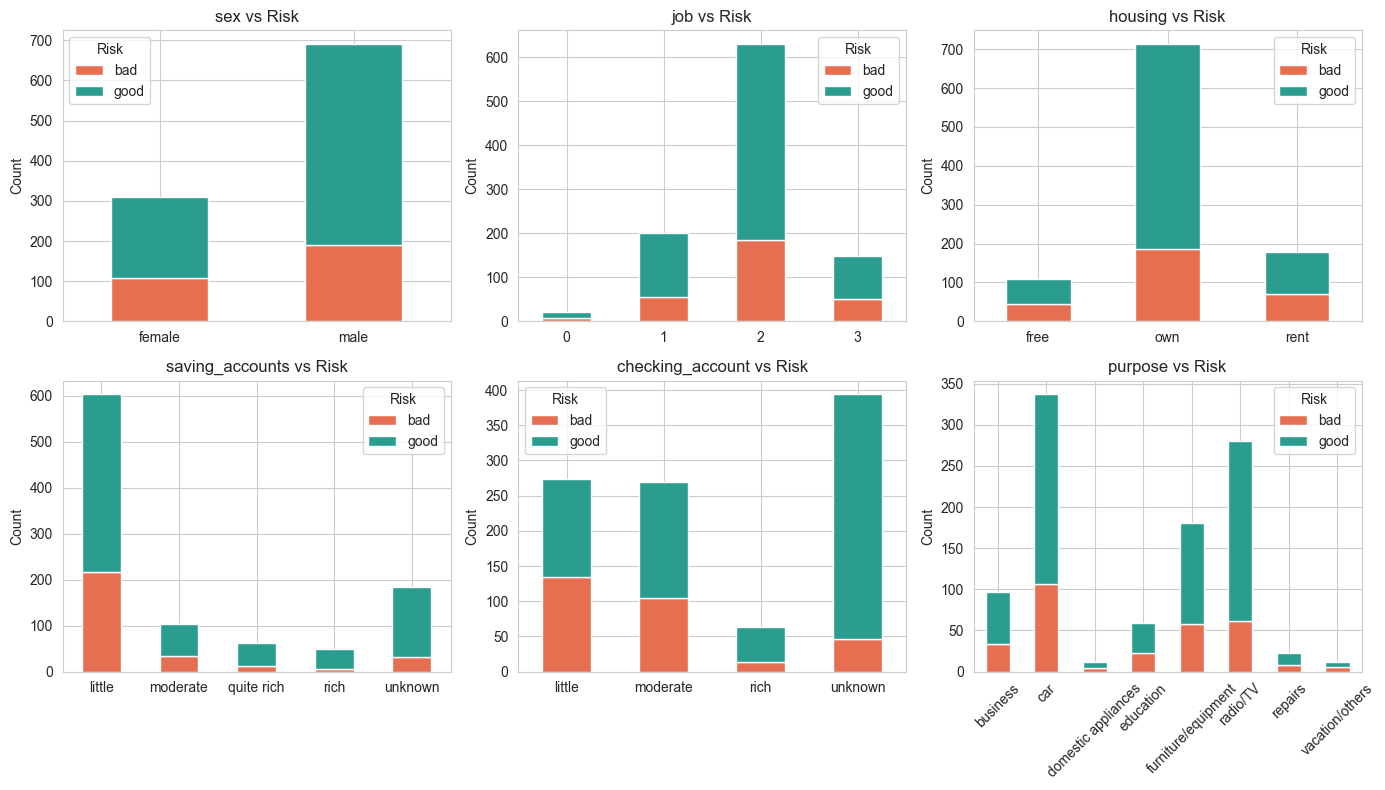

In [78]:
fig, axis = plt.subplots(2, 3, figsize=(14, 8))
axis = axis.flatten()

risk_colors = {
    "bad": "#e76f51",   # red
    "good": "#2a9d8f"   # green
}

for i, col in enumerate(cat_features):

    # raw counts by category + risk
    risk_dist = pd.crosstab(
        df[col],
        df["risk"]
    )

    risk_dist.plot(
        kind="bar",
        stacked=True,
        ax=axis[i],
        color=[risk_colors["bad"], risk_colors["good"]]
    )

    axis[i].set_title(f"{col} vs Risk")
    axis[i].set_xlabel("")
    axis[i].set_ylabel("Count")
    axis[i].legend(title="Risk")

    if col == "purpose":
        axis[i].tick_params(axis="x", labelrotation=45)
    else:
        axis[i].tick_params(axis="x", labelrotation=0)

plt.tight_layout()
plt.show()

**Insights — categorical features vs. risk (5.3.2)**

These **stacked count** bars compare how **good vs. bad** mix within each category (always read them together with how **large** each category is).

- **Checking account**: the **“little”** balance segment shows a much **higher** share of **bad** risk than **“rich”**; the **“unknown”** level (imputed missing) has a **lower observed** bad rate—treat **unknown** as its own segment rather than assuming it equals low risk.
- **Saving accounts**: **“little”** savings aligns with **higher** bad rates than **“quite rich”** / **“rich”** tiers, which is aligned with classic creditworthiness intuition.
- **Housing**: **“free”** and **“rent”** show **higher** bad shares than **“own”** in this dataset (subject to confounding with income and stability not observed here).
- **Sex**: **female** applicants have a **higher raw** bad rate than **male** in this sample—report for transparency, but review **fairness**, **legal constraints**, and **causal interpretation** before using sex in production decisions.
- **Purpose**: among categories with enough volume, **education** and **business** show **higher** bad rates than **radio/TV**, suggesting loan-use context may matter for risk.

Next steps: encode these as model features, monitor **bad rates by segment** over time, and validate that patterns hold on holdout data.


### 5.4 Multivariate Analysis

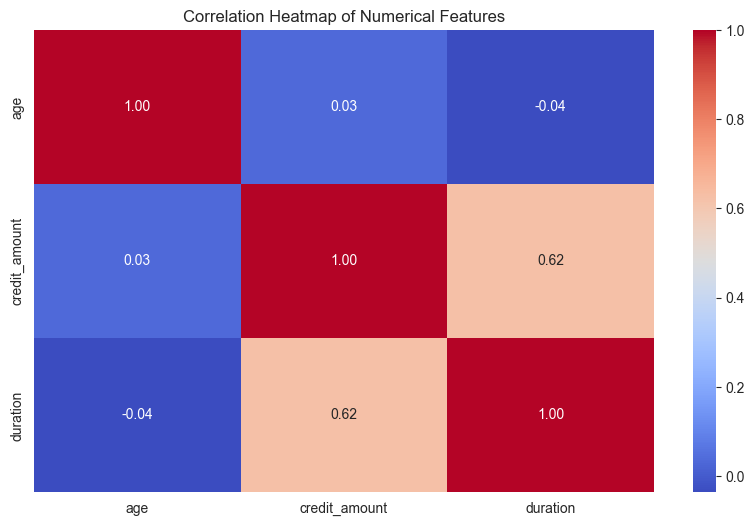

In [79]:
plt.figure(figsize=(10, 6))
sns.heatmap(
    df[["age", "credit_amount", "duration"]].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()


**Insights — correlation of numerical features (5.4)**

- **Credit amount** and **duration** are **moderately positively correlated** (**r ≈ 0.63**): larger loans tend to have **longer** terms. Linear models may **share variance** between them; tree ensembles or regularized linear models handle overlap more gracefully—check **coefficients / SHAP** jointly rather than in isolation.
- **Age** correlates more **weakly** with amount and duration, so it can add **partially independent** information alongside the two stronger financial drivers.

No pair is at a correlation so extreme that non-linear methods are mandatory solely for collinearity, but **amount–duration** coupling should be kept in mind when explaining feature effects.


## 6. Feature Engineering

### 6.1 Target Encoding and Feature Transformation

In [80]:
df['risk'] = df['risk'].map({
    'bad': 1,
    'good': 0
})

df["credit_amount_log"] = np.log1p(df["credit_amount"])

### 6.2 Define Features and Target Variable

In [81]:
X = df.drop(columns=['risk', 'credit_amount'])
y = df['risk']

### 6.3 Identify Feature Types

In [82]:
# numerical features
num_features = [
    "age",
    "credit_amount_log",
    "duration"
]

# ordinal categorical features
ordinal_features = [
    "job",
    "saving_accounts",
    "checking_account"
]

# nominal categorical features
nominal_features = [
    "sex",
    "housing",
    "purpose"
]

print("Numerical Features:", num_features)
print("Ordinal Features:", ordinal_features)
print("Nominal Features:", nominal_features)

Numerical Features: ['age', 'credit_amount_log', 'duration']
Ordinal Features: ['job', 'saving_accounts', 'checking_account']
Nominal Features: ['sex', 'housing', 'purpose']


### 6.4 Preprocessing Pipeline


Different feature groups use different transformations:

- **Numeric** features: standardized for distance-based models (e.g. logistic regression).
- **Ordinal** features: encoded with order preserved.
- **Nominal** features: one-hot encoded to avoid false distance between categories.


In [83]:
saving_categories = [
    "unknown",
    "little",
    "moderate",
    "quite rich",
    "rich"
]

checking_categories = [
    "unknown",
    "little",
    "moderate",
    "rich"
]

job_categories = [0, 1, 2, 3]

In [84]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            num_features
        ),

        (
            "nom",
            OneHotEncoder(handle_unknown="ignore"),
            nominal_features
        ),

        (
            "ord",
            OrdinalEncoder(categories=[
                job_categories,
                saving_categories,
                checking_categories
            ]),
            ordinal_features
        )
    ]
)

### 6.5 Train–test split


In [85]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


In [86]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

print("\nTrain Target Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTest Target Distribution:")
print(y_test.value_counts(normalize=True))


X_train shape: (800, 9)
X_test shape: (200, 9)

Train Target Distribution:
risk
0    0.7
1    0.3
Name: proportion, dtype: float64

Test Target Distribution:
risk
0    0.7
1    0.3
Name: proportion, dtype: float64


## 7. Modeling

### 7.1 Define Evaluation Function

In [87]:
def evaluate_model(y_true, y_pred, y_proba):

    metrics = {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall": recall_score(y_true, y_pred),
        "F1-Score": f1_score(y_true, y_pred),
        "ROC-AUC": roc_auc_score(y_true, y_proba),
    }
    cm = confusion_matrix(y_true, y_pred)
    cr = classification_report(y_true, y_pred)

    return metrics, cm, cr

### 7.2 Logistic Regression

In [88]:
log_reg_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        class_weight="balanced",
        max_iter=1000,
        random_state=42
    )),
])

### 7.3 Random Forest

In [89]:
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=300,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight="balanced",
        random_state=42,
    )),
])

### 7.4 XGBoost

In [90]:
neg = (y_train == 0).sum()
pos = (y_train == 1).sum()

scale_pos_weight = neg / pos

xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric="logloss",
        scale_pos_weight=scale_pos_weight,
        random_state=42
    ))

])

### 7.5 Train All Models

In [91]:
# Logistic Regression
log_reg_model.fit(X_train, y_train)

# Random Forest
rf_model.fit(X_train, y_train)

# XGBoost
xgb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('nom', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [92]:
# Logistic Regression
y_pred_lr = log_reg_model.predict(X_test)
y_proba_lr = log_reg_model.predict_proba(X_test)[:, 1]

# Random Forest
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# XGBoost
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

In [93]:
lr_results, lr_cm, lr_cr = evaluate_model(y_test, y_pred_lr, y_proba_lr)
rf_results, rf_cm, rf_cr = evaluate_model(y_test, y_pred_rf, y_proba_rf)
xgb_results, xgb_cm, xgb_cr = evaluate_model(y_test, y_pred_xgb, y_proba_xgb)

### 7.6 Compare Model Performance

In [94]:
comparison_df = pd.DataFrame([
    lr_results,
    rf_results,
    xgb_results

], index=[
    "Logistic Regression",
    "Random Forest",
    "XGBoost"
])

In [95]:
comparison_df

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Logistic Regression,0.645,0.430380,0.566667,0.489209,0.673214
Random Forest,0.720,0.533333,0.533333,0.533333,0.776548
XGBoost,0.740,0.555556,0.666667,0.606061,0.777024


In [96]:
from sklearn.metrics import roc_curve, auc

# calculate ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)

# calculate AUC values
auc_lr = auc(fpr_lr, tpr_lr)
auc_rf = auc(fpr_rf, tpr_rf)
auc_xgb = auc(fpr_xgb, tpr_xgb)

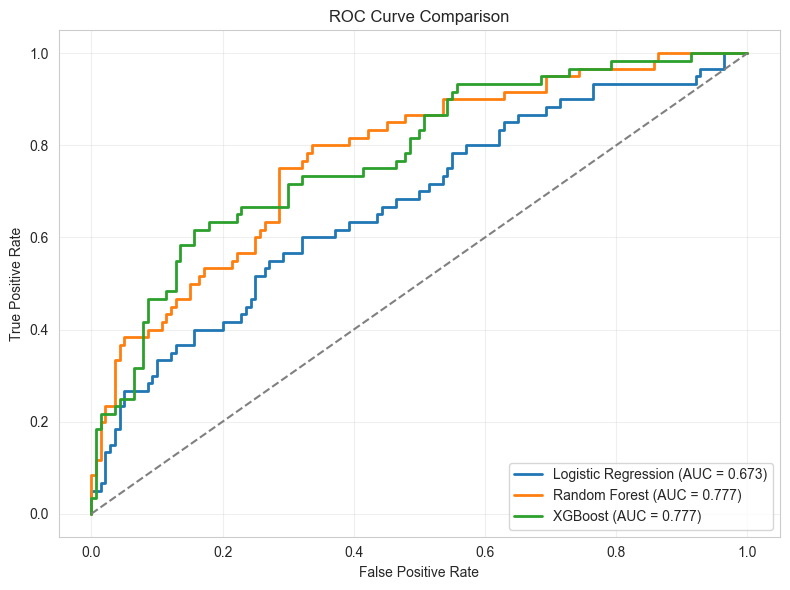

In [97]:
plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr,
         label=f"Logistic Regression (AUC = {auc_lr:.3f})",
         linewidth=2)

plt.plot(fpr_rf, tpr_rf,
         label=f"Random Forest (AUC = {auc_rf:.3f})",
         linewidth=2)

plt.plot(fpr_xgb, tpr_xgb,
         label=f"XGBoost (AUC = {auc_xgb:.3f})",
         linewidth=2)

# random baseline
plt.plot([0,1], [0,1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### 7.7 Hyperparameter tuning


In [98]:
## n_estimators -> 100 - 1000
## learning_rate -> 0.01 - 0.3
## max_depth -> 3 - 10
## subsample -> 0.5 - 1.0
## colsample_bytree -> 0.5 - 1.0
## min_child_weight -> 1 - 10
## gamma -> 0 - 5 
## scale_pos_weight = negative / positive 
    #* 1 = no weighting
    #* 2 – 5 = moderate imbalance
    #* 10+ = severe imbalance

param_dist = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [3, 4, 5],
    "model__learning_rate": [0.03, 0.05, 0.1],
    "model__subsample": [0.7, 0.8, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 1.0],
    "model__min_child_weight": [1, 3, 5],
    "model__gamma": [0, 0.1, 0.3]
}
from sklearn.model_selection import RandomizedSearchCV

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=5,
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__gamma': [0, 0.1, ...], 'model__learning_rate': [0.03, 0.05, ...], 'model__max_depth': [3, 4, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'roc_auc'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strate

In [99]:
print("Best CV ROC-AUC:", round(random_search.best_score_, 3))

Best CV ROC-AUC: 0.765


In [103]:
random_search.best_params_

{'model__subsample': 0.7,
 'model__n_estimators': 100,
 'model__min_child_weight': 1,
 'model__max_depth': 3,
 'model__learning_rate': 0.05,
 'model__gamma': 0.1,
 'model__colsample_bytree': 0.8}

In [102]:
best_xgb = random_search.best_estimator_

y_pred_best = best_xgb.predict(X_test)
y_proba_best = best_xgb.predict_proba(X_test)[:,1]

best_xgb_results,_,_ = evaluate_model(
    y_test,
    y_pred_best,
    y_proba_best
)

pd.DataFrame(best_xgb_results, index=["Tuned XGBoost"]).T

,Tuned XGBoost
Accuracy,0.705000
Precision,0.505618
Recall,0.750000
F1-Score,0.604027
ROC-AUC,0.776905


The next cells tune the **decision threshold** (7.8) and document **optional imbalance experiments** (7.9–7.10) using the same train/test protocol.


### 7.8 Threshold Optimization

**Threshold optimization (7.8)**

The default score cutoff (`0.50`) is not always optimal for credit decisions.

- Lower thresholds usually increase **recall** for bad risk (catch more defaulters) at the cost of **precision** (more false alarms).
- Higher thresholds do the opposite.

We sweep plausible cutoffs and pick an operating point that balances business tolerance for false positives vs false negatives.


In [104]:
y_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]

In [105]:
thresholds = np.arange(0.30, 0.71, 0.05)

threshold_results = []

for threshold in thresholds:
    
    y_pred_threshold = (
        y_proba_xgb >= threshold
    ).astype(int)
    
    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            y_pred_threshold
        ),
        "Recall": recall_score(
            y_test,
            y_pred_threshold
        ),
        "F1-Score": f1_score(
            y_test,
            y_pred_threshold
        )
    })

threshold_df = pd.DataFrame(
    threshold_results
)

In [106]:
threshold_df.round(3)

,Threshold,Precision,Recall,F1-Score
0,0.30,0.388,0.867,0.536
1,0.35,0.455,0.850,0.593
2,0.40,0.471,0.800,0.593
3,0.45,0.474,0.767,0.586
4,0.50,0.506,0.750,0.604
5,0.55,0.513,0.650,0.574
6,0.60,0.547,0.583,0.565
7,0.65,0.564,0.517,0.539
8,0.70,0.676,0.417,0.515


### 7.9 Class imbalance experiment: random oversampling


In [ ]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [ ]:
from imblearn.over_sampling import RandomOverSampler

ros = RandomOverSampler(random_state=42)

X_train_resampled, y_train_resampled = ros.fit_resample(
    X_train_processed,
    y_train
)

In [ ]:
print(y_train.value_counts())
print(y_train_resampled.value_counts())

In [ ]:
y_pred_xgb_ros = xgb_resampled.predict(X_test_processed)
y_proba_xgb_ros = xgb_resampled.predict_proba(X_test_processed)[:, 1]

xgb_ros_results, _, _ = evaluate_model(
    y_test,
    y_pred_xgb_ros,
    y_proba_xgb_ros
)

pd.DataFrame(
    xgb_ros_results,
    index=["XGBoost + Oversampling"]

### 7.10 Class imbalance experiment: SMOTE


In [ ]:
from imblearn.over_sampling import SMOTE

In [108]:
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [109]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

In [110]:
print(y_train.value_counts())
print(y_train_smote.value_counts())

risk
0    560
1    240
Name: count, dtype: int64
risk
1    560
0    560
Name: count, dtype: int64


In [111]:
best_params = best_xgb.named_steps["model"].get_params()

xgb_smote = XGBClassifier(**best_params)

xgb_smote.fit(X_train_smote, y_train_smote)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [112]:
# predict on test set
y_pred_smote = xgb_smote.predict(X_test_processed)
y_proba_smote = xgb_smote.predict_proba(X_test_processed)[:, 1]

# evaluate performance
smote_results, _, _ = evaluate_model(
    y_test,
    y_pred_smote,
    y_proba_smote
)

# display results
pd.DataFrame(
    smote_results,
    index=["Tuned XGBoost + SMOTE"]
).T

,Tuned XGBoost + SMOTE
Accuracy,0.675000
Precision,0.475248
Recall,0.800000
F1-Score,0.596273
ROC-AUC,0.759167


## 8. Final model interpretation

The **tuned weighted XGBoost** model is used as the primary production candidate (strong discrimination on ROC–AUC and stable metrics on the hold-out set).

**What follows**

- **Feature importance** (Section 8.1): which inputs drive risk scores.
- **Confusion matrix at the chosen threshold** (Section 8.2): how errors split in practice.

These views support both model governance and business communication (underwriting, monitoring, and policy).


### 8.1 Feature Importance

In [ ]:
# Get Feature Names After Preprocessing
feature_names = best_xgb.named_steps['preprocessor'].get_feature_names_out()

# Get Importance Values
importance_values = best_xgb.named_steps['model'].feature_importances_

In [118]:
# Build DataFrame for Feature Importance
importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})
# Sort by Importance
importance_df = importance_df.sort_values(
    by="Importance",
    ascending=False
)

In [121]:
importance_df.head(155)

,Feature,Importance
18,ord__checking_account,0.170354
2,num__duration,0.070081
13,nom__purpose_radio/TV,0.065588
4,nom__sex_male,0.063717
17,ord__saving_accounts,0.058734
6,nom__housing_own,0.056976
11,nom__purpose_education,0.056785
14,nom__purpose_repairs,0.054836
1,num__credit_amount_log,0.054049
3,nom__sex_female,0.052539


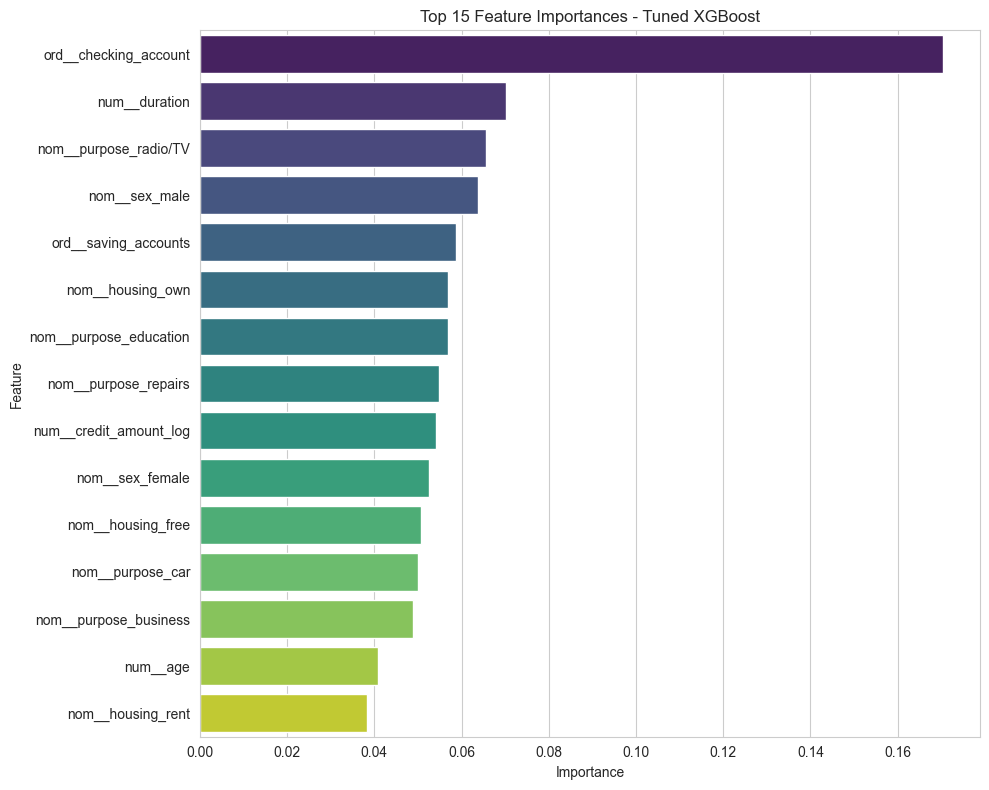

In [122]:
plt.figure(figsize=(10, 8))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance_df.head(15),
    palette="viridis"
)

plt.title("Top 15 Feature Importances - Tuned XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

### 8.2 Final Confusion Matrix

In [123]:
final_threshold = 0.45

y_proba_final = best_xgb.predict_proba(X_test)[:, 1]

y_pred_final = (
    y_proba_final >= final_threshold
).astype(int)

In [124]:
cm = confusion_matrix(
    y_test,
    y_pred_final
)

cm

array([[89, 51],
       [14, 46]])

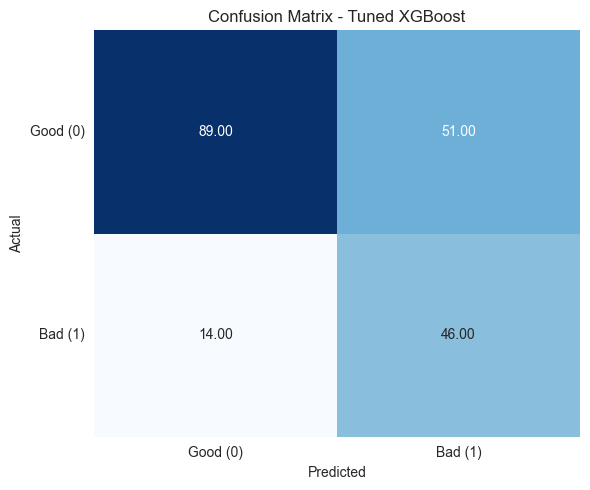

In [125]:
plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
)

plt.title("Confusion Matrix - Tuned XGBoost")

plt.xlabel("Predicted")
plt.ylabel("Actual")



plt.xticks(

    [0.5, 1.5],

    ["Good (0)", "Bad (1)"]

)

plt.yticks(

    [0.5, 1.5],

    ["Good (0)", "Bad (1)"],

    rotation=0

)

plt.tight_layout()

plt.show()

## 9. Business Conclusions

### What was built

A supervised credit risk classification model was developed on the German Credit dataset to predict **bad vs good** applicants.  
The workflow included strict train/test separation, pipeline-based preprocessing, and benchmarking against Logistic Regression and Random Forest models.

### Final Model Choice

A tuned XGBoost model provided the strongest overall balance between predictive power and detection of risky applicants, and was selected as the final solution.

### Key Risk Drivers

The model indicates that the following variables are especially relevant:

- **Loan amount and duration**: larger and longer obligations are associated with higher repayment risk.  
- **Checking and savings account behaviour**: account status, including an explicit **unknown** category, contributes meaningfully to borrower segmentation and credit risk assessment.

### Operational Deployment

The selected operating threshold is **0.45** on predicted bad-risk probability.

Applicants above this level would be flagged for rejection, manual review, or tighter lending conditions.

This threshold should be reviewed whenever business priorities change (growth vs risk control, false positives vs missed defaults).

### Resampling Experiments

Oversampling and SMOTE were tested as transparent alternatives.

While they improved recall in some cases, they generally reduced precision and/or ROC-AUC.

Therefore, the weighted tuned XGBoost model remained the preferred production candidate.